In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
df = pd.read_csv('healthcare_dataset.csv')

df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [15]:
#df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [16]:
#Bu kısımda tarih formatını değiştirmek için kullanılıyor.
#Formatları sayısal hale getirerek toplam kaldığı süreyi hesaplamak için kullanıyoruz.
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

In [17]:
df['Day of Rest'] = -1*(df['Date of Admission'] - df['Discharge Date'])


In [4]:
season_map = {
    12: 'Kış', 1: 'Kış', 2: 'Kış',
    3: 'İlkbahar', 4: 'İlkbahar', 5: 'İlkbahar',
    6: 'Yaz', 7: 'Yaz', 8: 'Yaz',
    9: 'Sonbahar', 10: 'Sonbahar', 11: 'Sonbahar'
}

In [18]:
df['month'] = df['Date of Admission'].dt.month_name()



In [19]:
df['month'].unique()

array(['January', 'August', 'September', 'November', 'December', 'July',
       'May', 'April', 'October', 'June', 'March', 'February'],
      dtype=object)

In [20]:
df.drop(columns=['Date of Admission','Name','Discharge Date','Room Number'], inplace=True)

In [21]:
df.columns

df.head()

df.info()

df.describe()

df.isnull().sum()

df.dropna(inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   Age                 55500 non-null  int64          
 1   Gender              55500 non-null  object         
 2   Blood Type          55500 non-null  object         
 3   Medical Condition   55500 non-null  object         
 4   Doctor              55500 non-null  object         
 5   Hospital            55500 non-null  object         
 6   Insurance Provider  55500 non-null  object         
 7   Billing Amount      55500 non-null  float64        
 8   Admission Type      55500 non-null  object         
 9   Medication          55500 non-null  object         
 10  Test Results        55500 non-null  object         
 11  Day of Rest         55500 non-null  timedelta64[ns]
 12  month               55500 non-null  object         
dtypes: float64(1), int64(1), object

In [40]:
df.to_csv('current_data.csv', index=False)

In [35]:
print(df['Billing Amount'].describe())

count    55500.000000
mean     25539.316097
std      14211.454431
min      -2008.492140
25%      13241.224652
50%      25538.069376
75%      37820.508436
max      52764.276736
Name: Billing Amount, dtype: float64


In [ ]:
(df['Billing Amount'] < 0).sum()




np.int64(108)

In [39]:
# Negatif 'Billing Amount' değerlerini ortalama ile değiştir
col = 'Billing Amount'
mask_neg = df[col] < 0
neg_count_before = mask_neg.sum()

# Negatif olmayanlardan ortalama hesapla; yoksa genel ortalamaya, o da yoksa 0'a düş
mean_nonneg = df.loc[~mask_neg, col].mean()
if pd.isna(mean_nonneg):
    mean_nonneg = df[col].mean()
if pd.isna(mean_nonneg):
    mean_nonneg = 0.0

# Değiştirme
if neg_count_before > 0:
    df.loc[mask_neg, col] = mean_nonneg

neg_count_after = (df[col] < 0).sum()
print(f"Değiştirilen kayıt sayısı: {neg_count_before}")
print(f"Kullanılan ortalama değer: {mean_nonneg:.2f}")
print(f"İşlem sonrası negatif kayıt sayısı: {neg_count_after}")


Değiştirilen kayıt sayısı: 108
Kullanılan ortalama değer: 25590.08
İşlem sonrası negatif kayıt sayısı: 0


In [41]:
# Fiyatları aralıklara böl ve yeni sütun oluştur
col = 'Billing Amount'
# Güvenlik: Sayısal olsun
df[col] = pd.to_numeric(df[col], errors='coerce')

# Aralık sınırları (örnek + eksik 30-40k eklendi, 60k+ için üst sınıf)
bins = [0, 10_000, 20_000, 30_000, 40_000, 50_000, 60_000]
labels = ['0-10k', '10-20k', '20-30k', '30-40k', '40-50k', '50-60k']

# 60k+ ve 0 altı değerler için opsiyonel geniş aralıklar eklemek isterseniz:
# bins = [-np.inf, 0, 10_000, 20_000, 30_000, 40_000, 50_000, 60_000, np.inf]
# labels = ['<0', '0-10k', '10-20k', '20-30k', '30-40k', '40-50k', '50-60k', '60k+']

# pd.cut ile kategorize et (0 dahil, 60k dahil değil)
df['Billing Amount Bin'] = pd.cut(
    df[col],
    bins=bins,
    labels=labels,
    right=True,  # (a, b] sağ kapalı
    include_lowest=True
)

# Özet
print(df['Billing Amount Bin'].value_counts(dropna=False))
df[['Billing Amount', 'Billing Amount Bin']].head()


Billing Amount Bin
20-30k    11499
30-40k    11240
10-20k    11187
40-50k    10972
0-10k     10144
50-60k      458
Name: count, dtype: int64


,Billing Amount,Billing Amount Bin
0,18856.281306,10-20k
1,33643.327287,30-40k
2,27955.096079,20-30k
3,37909.782410,30-40k
4,14238.317814,10-20k


In [44]:
# Age sütununu 5 yıllık aralıklara böl (0-5, 5-10, ..., 90-95)
col_age = 'Age'
df[col_age] = pd.to_numeric(df[col_age], errors='coerce')

# 0-5 ... 90-95 aralıkları için sınırlar
age_bins = np.arange(0, 100, 5)  # [0, 5, 10, ..., 95]
age_labels = [f"{age_bins[i]}-{age_bins[i+1]}" for i in range(len(age_bins) - 1)]

# Not: 95 üzeri yaşlar NaN olur. İsterseniz 95+ için şu şekilde ekleyin:
# age_bins = list(np.arange(0, 100, 5)) + [np.inf]
# age_labels = [f"{age_bins[i]}-{age_bins[i+1]}" for i in range(len(age_bins) - 2)] + ["95+"]

df['Age Bin 5y'] = pd.cut(
    df[col_age],
    bins=age_bins,
    labels=age_labels,
    right=True,
    include_lowest=True,
    ordered=True
)

# Özet dağılım
print(df['Age Bin 5y'].value_counts(dropna=False).sort_index())
df[[col_age, 'Age Bin 5y']].head()


Age Bin 5y
0-5         0
5-10        0
10-15      60
15-20    2383
20-25    4102
25-30    3954
30-35    4033
35-40    4092
40-45    4105
45-50    4104
50-55    4115
55-60    4182
60-65    4120
65-70    4108
70-75    3988
75-80    4119
80-85    3930
85-90     105
90-95       0
Name: count, dtype: int64


,Age,Age Bin 5y
0,30,25-30
1,62,60-65
2,76,75-80
3,28,25-30
4,43,40-45


<Axes: xlabel='Age Bin 5y', ylabel='Billing Amount Bin'>

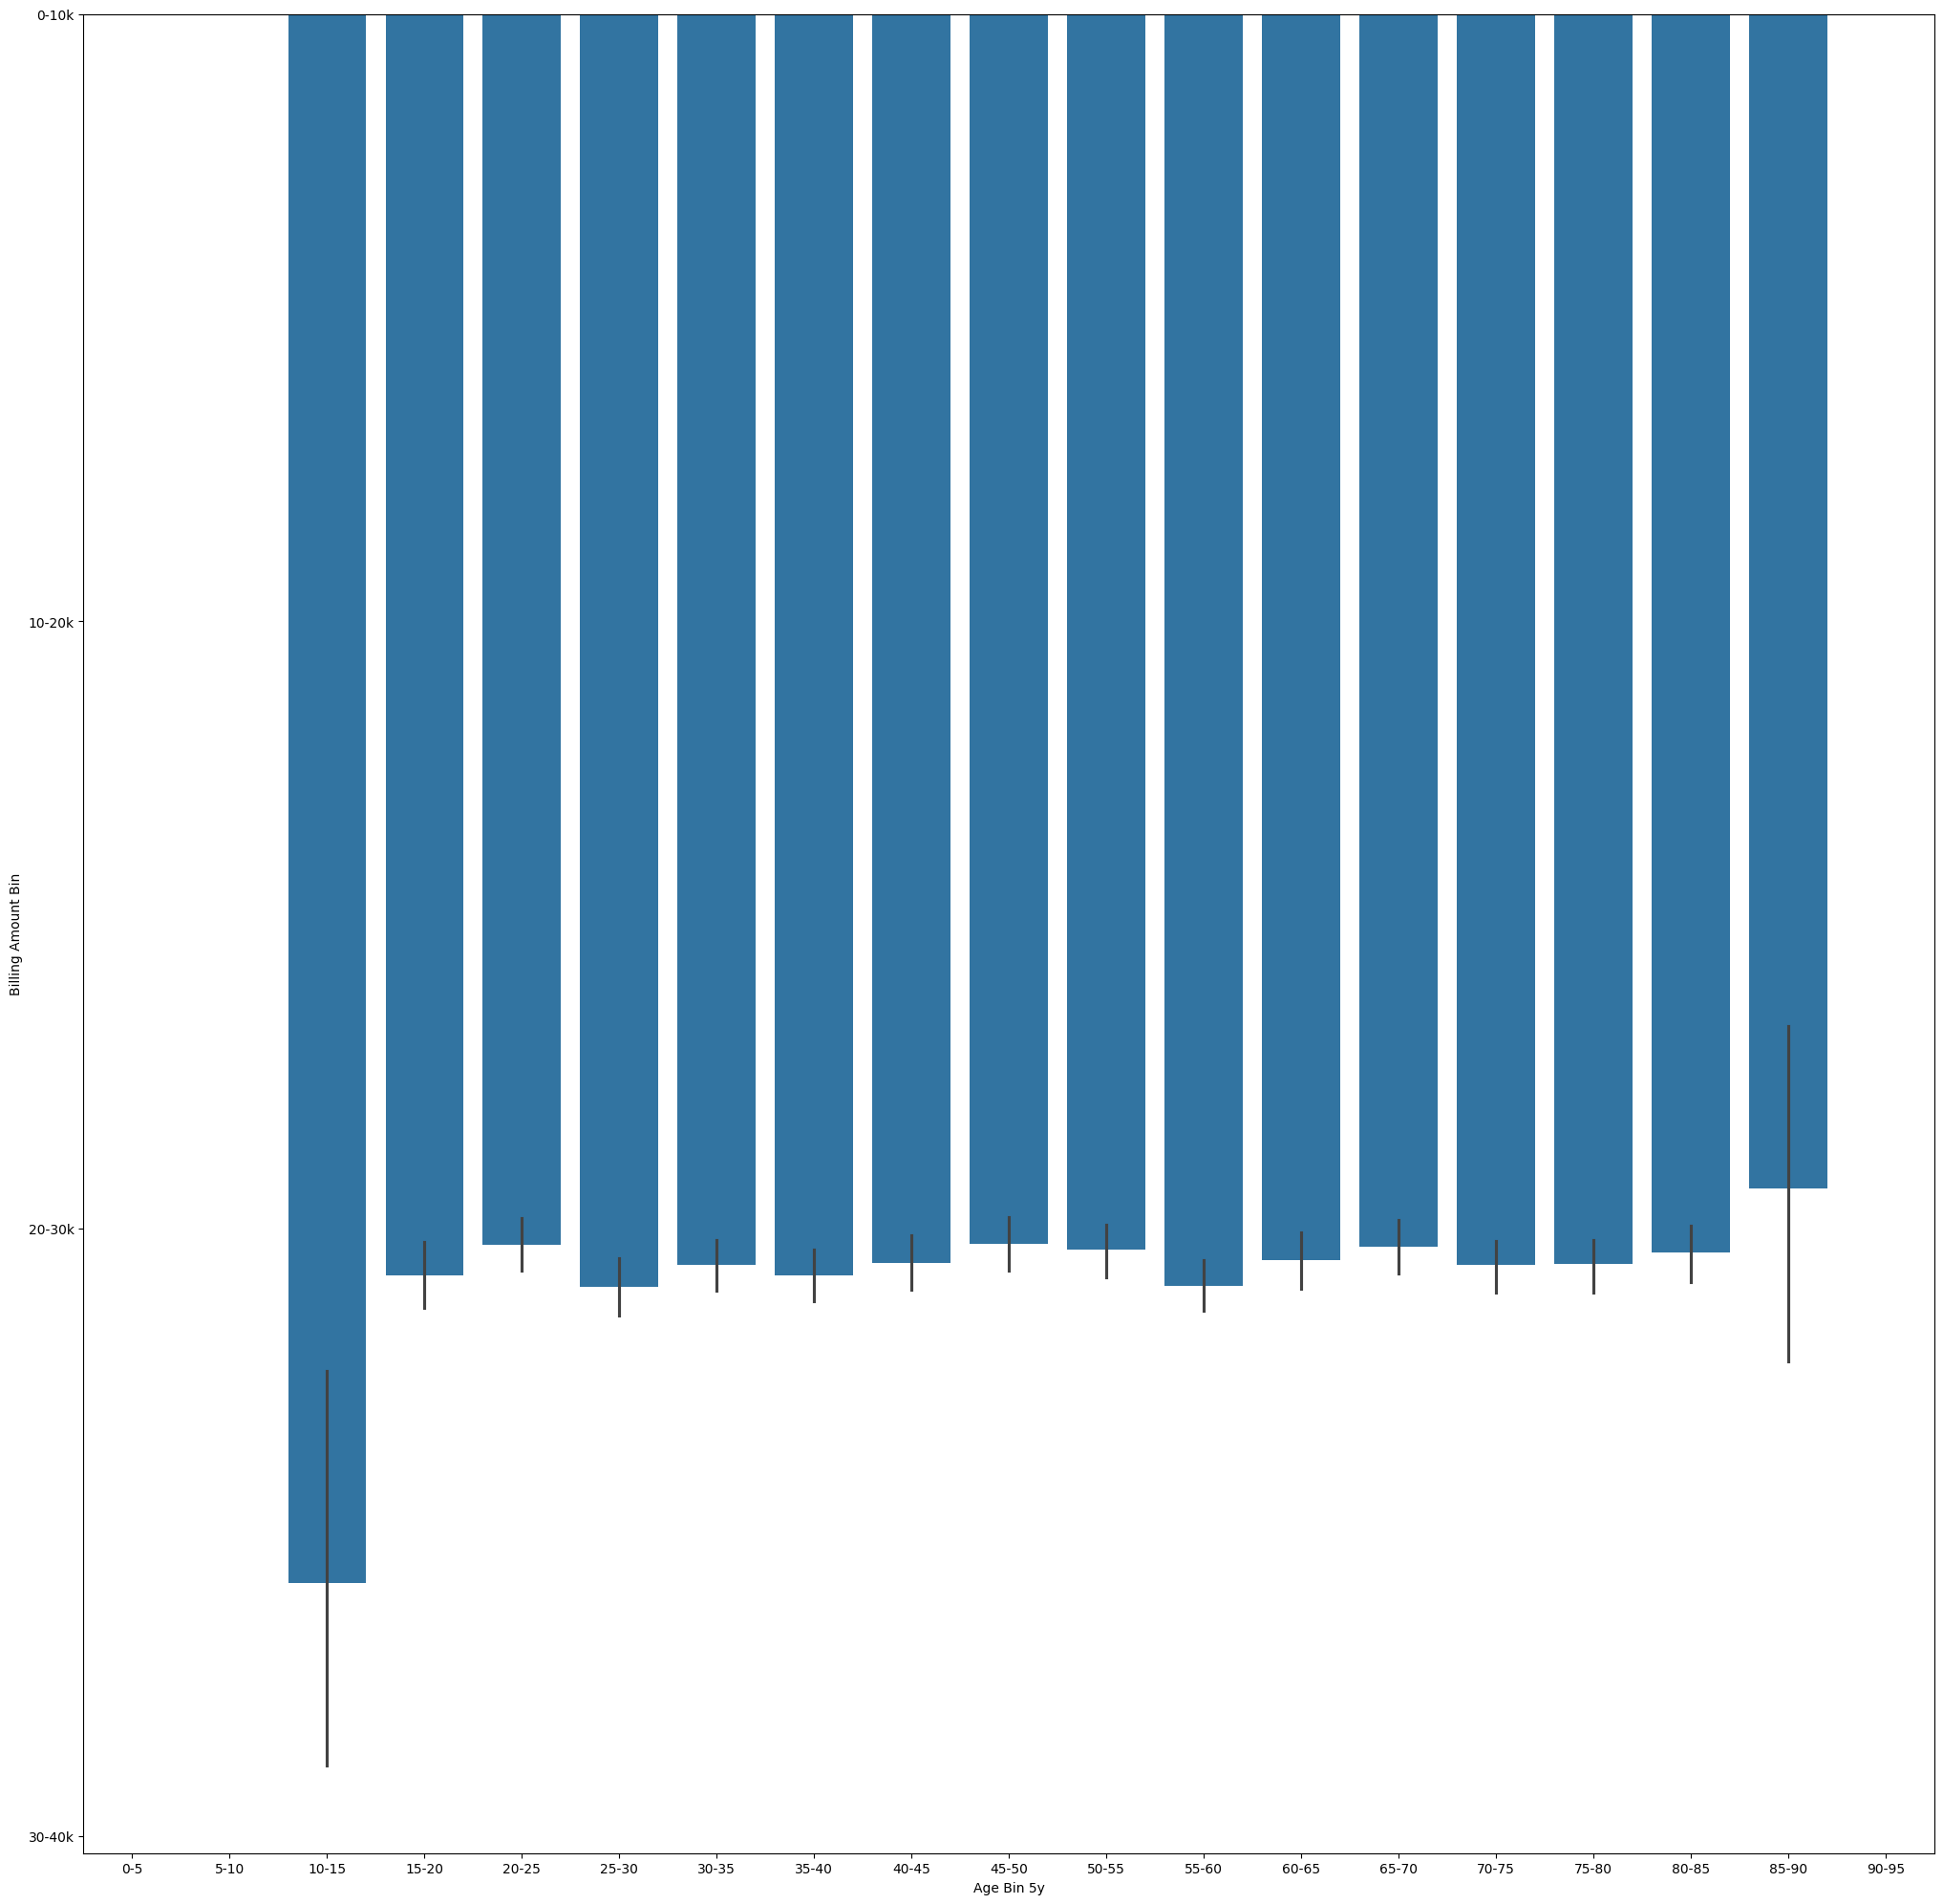

In [49]:
plt.figure(figsize=(25, 25))

sns.barplot(x = 'Age Bin 5y', y = 'Billing Amount Bin', data = df)

In [50]:
df.to_csv('current_data.csv', index=False)

<Axes: xlabel='Billing Amount', ylabel='Blood Type'>

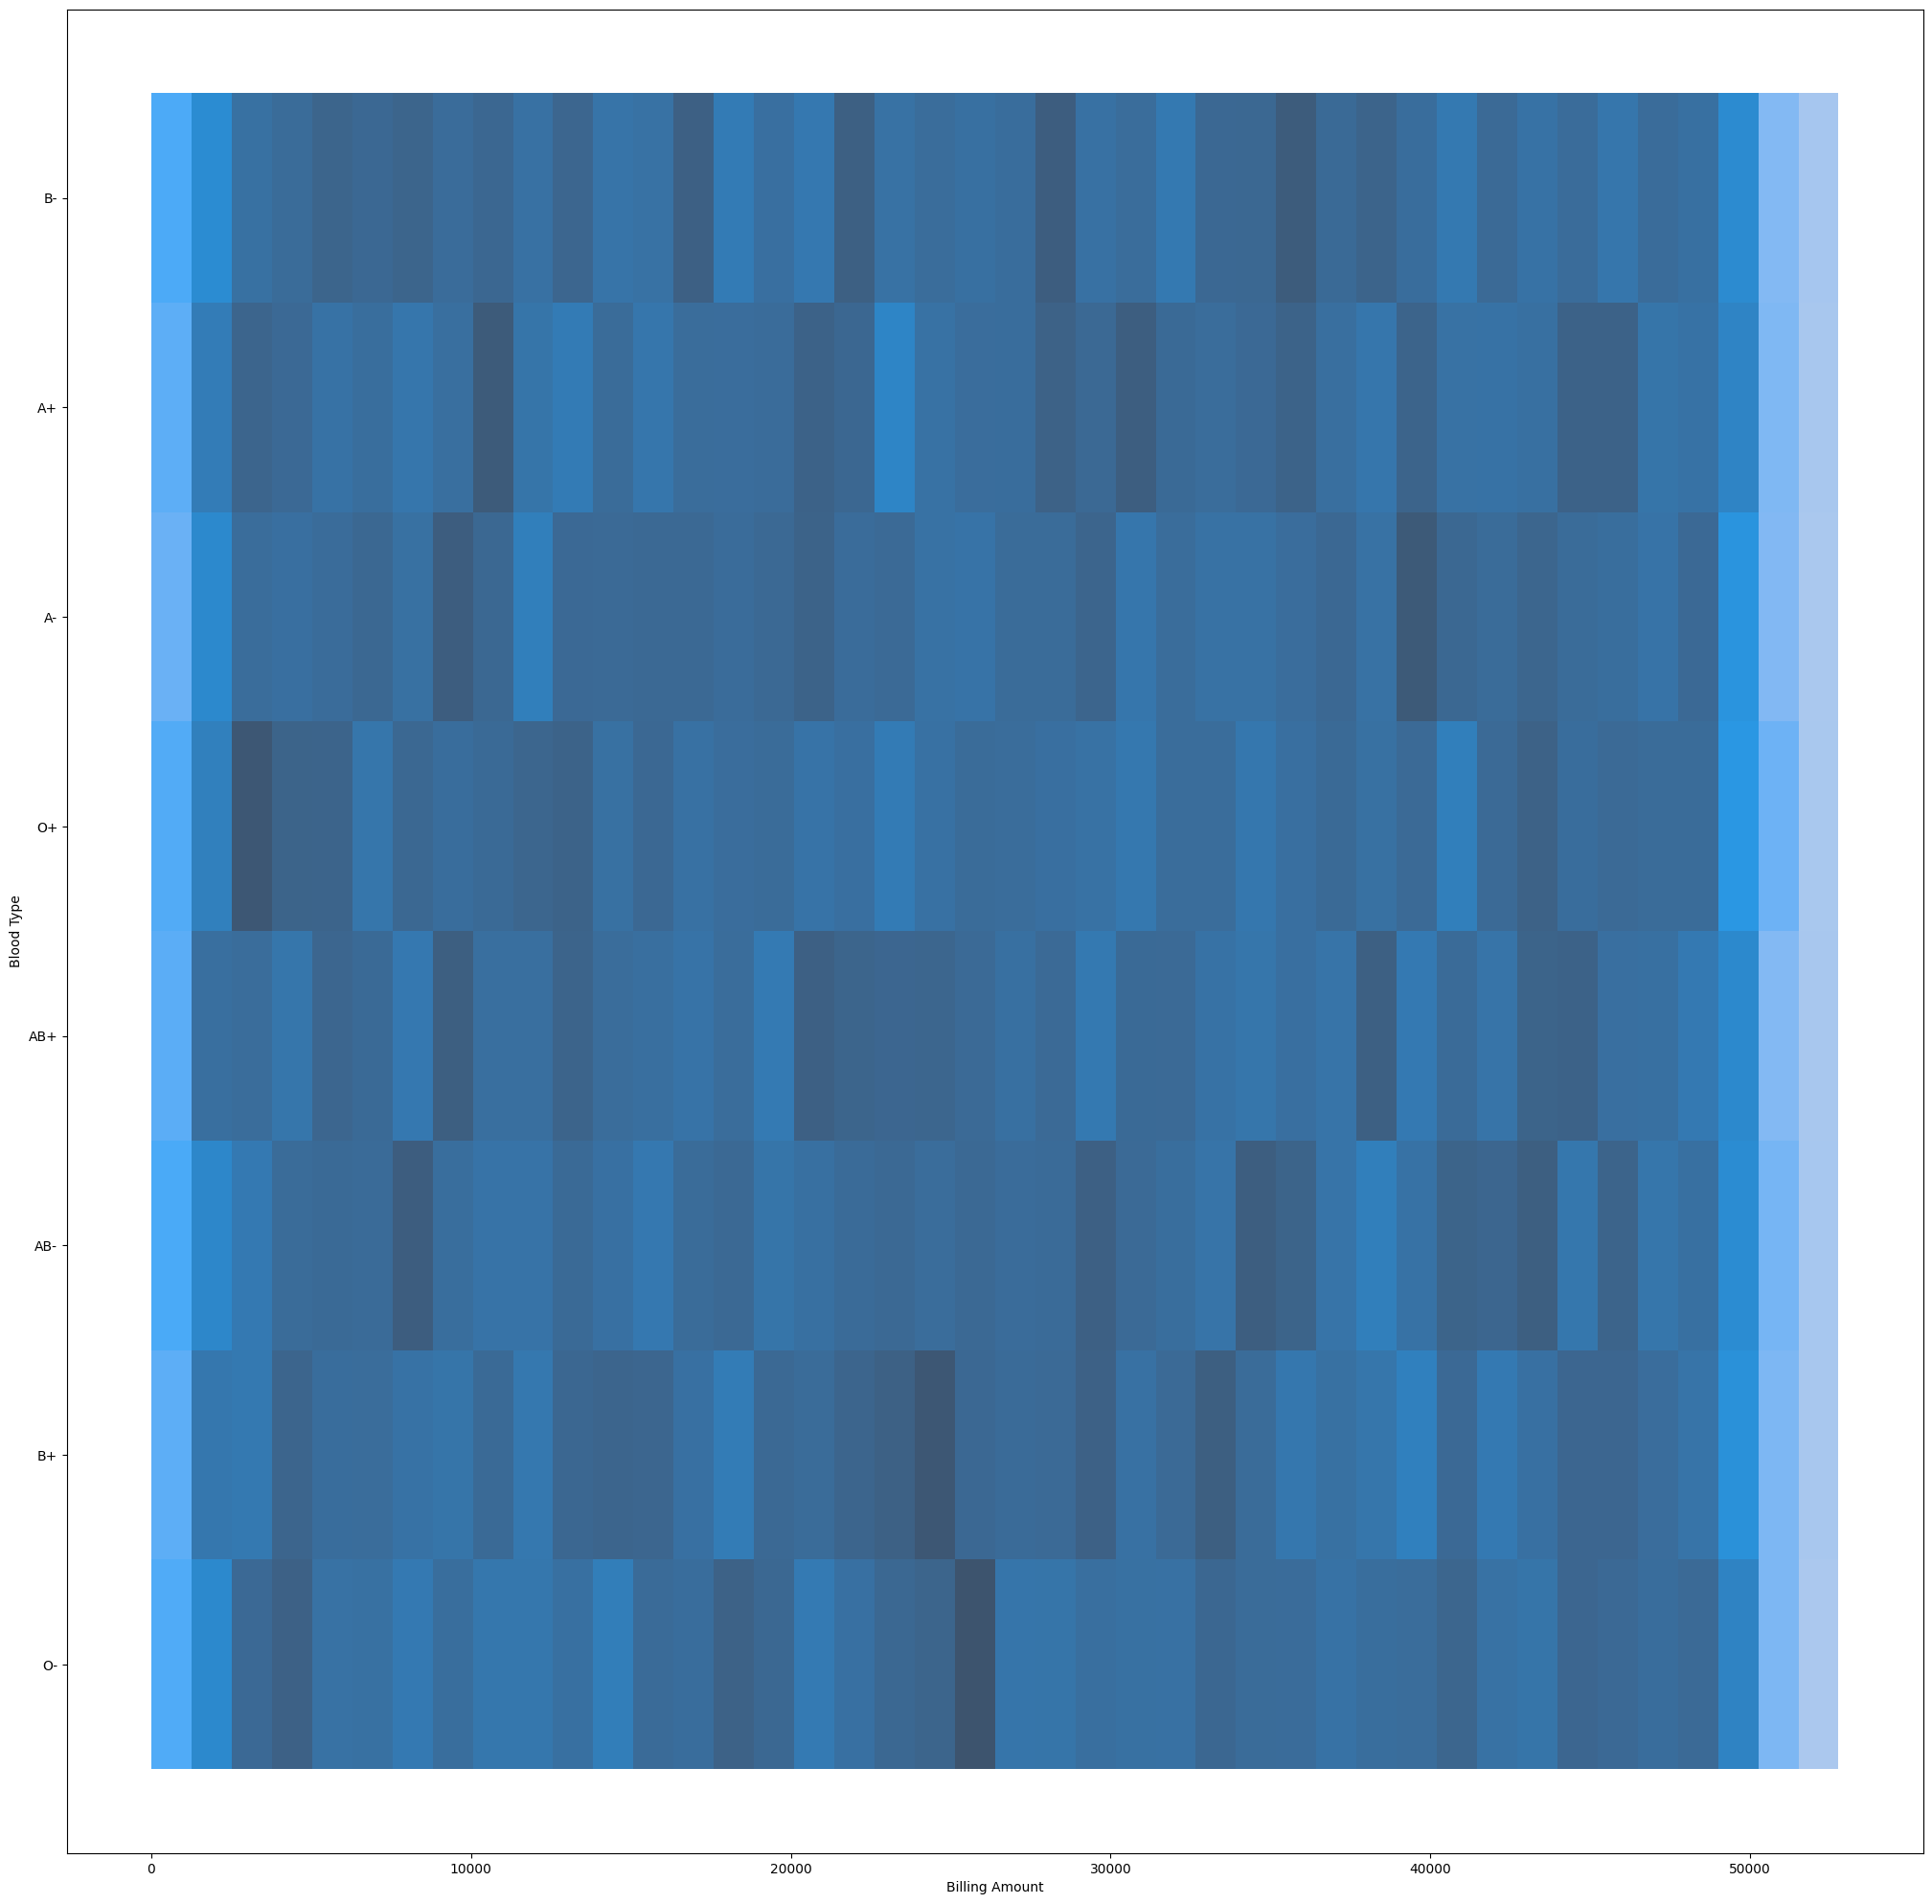

In [51]:
plt.figure(figsize=(25, 25))

sns.histplot(x = 'Billing Amount', y = 'Blood Type', data = df)